In [ ]:
#|default_exp resnet

# ResNets

In [ ]:
import sys
sys.path.insert(0, '/home/tzyy/projects/course22p2_zh')

In [ ]:
#|export
import pickle,gzip,math,os,time,shutil,torch,matplotlib as mpl,numpy as np,matplotlib.pyplot as plt
import fastcore.all as fc
from collections.abc import Mapping
from pathlib import Path
from operator import attrgetter,itemgetter
from functools import partial
from copy import copy
from contextlib import contextmanager

import torchvision.transforms.functional as TF,torch.nn.functional as F
from torch import tensor,nn,optim
from torch.utils.data import DataLoader,default_collate
from torch.nn import init
from torch.optim import lr_scheduler
from torcheval.metrics import MulticlassAccuracy
from datasets import load_dataset,load_dataset_builder

from miniai.datasets import *
from miniai.conv import *
from miniai.learner import *
from miniai.activations import *
from miniai.init import *
from miniai.sgd import *

In [ ]:
from fastcore.test import test_close

torch.set_printoptions(precision=2, linewidth=140, sci_mode=False)
torch.manual_seed(1)
mpl.rcParams['image.cmap'] = 'gray'

import logging
logging.disable(logging.WARNING)

set_seed(42)

In [ ]:
xl,yl = 'image','label'
name = "fashion_mnist"
bs = 1024
xmean,xstd = 0.28, 0.35

@inplace
def transformi(b): b[xl] = [(TF.to_tensor(o)-xmean)/xstd for o in b[xl]]

dsd = load_dataset(name)
tds = dsd.with_transform(transformi)
dls = DataLoaders.from_dd(tds, bs, num_workers=4)

In [ ]:
#|export
act_gr = partial(GeneralRelu, leak=0.1, sub=0.4)

In [ ]:
help(ActivationStats)

Help on class ActivationStats in module miniai.activations:

class ActivationStats(HooksCallback)
 |  ActivationStats(mod_filter=<function noop at 0x7e2ac0f799e0>)
 |
 |  # %% ../nbs/10_activations.ipynb 58
 |
 |  Method resolution order:
 |      ActivationStats
 |      HooksCallback
 |      miniai.learner.Callback
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __init__(self, mod_filter=<function noop at 0x7e2ac0f799e0>)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  color_dim(self, figsize=(11, 5))
 |
 |  dead_chart(self, figsize=(11, 5))
 |
 |  plot_stats(self, figsize=(10, 4))
 |
 |  ----------------------------------------------------------------------
 |  Methods inherited from HooksCallback:
 |
 |  __iter__(self)
 |
 |  __len__(self)
 |
 |  after_fit(self, learn)
 |
 |  before_fit(self, learn)
 |
 |  ----------------------------------------------------------------------
 |  Data descriptors inherited from miniai.learner.Callback:
 |
 | 

Hook不也是一种callback吗，为什么不直接用callback而选择再嵌套一层，请你清晰明了地说明其设计逻辑

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好问题！这涉及到两个不同"维度"的功能分离：

**Callback** 管理的是**训练循环的时间轴**——什么时候做事情（`before_fit`、`after_batch`、`before_epoch` 等）。

**PyTorch Hook**（`register_forward_hook`）管理的是**模型内部的数据流**——在某个层的前向传播时截获数据。

它们是正交的。如果把这套 hook 的注册/移除/过滤/存储逻辑直接塞进 `Callback` 基类，那所有 callback 都会背上这套复杂机制，哪怕它们根本不需要窥探模型内部。

所以设计上的分层很清晰：

```
Callback              ← 只管"何时介入训练循环"
  └─ HooksCallback    ← 加上"如何给模型层挂 PyTorch hook"
       └─ ActivationStats  ← 具体用途：收集激活值统计
```

这样，像学习率调度、早停这类不需要碰模型内部的 callback 直接继承 `Callback` 就够了，干净轻量。只有需要"偷看"层输出的才走 `HooksCallback`。

<details class='token-usage-details' markdown='1'><summary>$0.0047</summary>

`total=9,685 | in=9,009 | out=676 | cached=35.5% | reasoning=440 | searches=0 | $0.0047`

</details>


是否因为Hook机制能够直接拿到模型的输入和输出

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

正是这个原因。

PyTorch 的 `register_forward_hook` 会在前向传播时，把每一层的 `(module, input, output)` 直接交到你手上——这是训练循环层面完全看不到的数据。`Callback.after_batch` 只能拿到 loss 和预测结果，根本不知道中间第 3 层卷积输出了什么。

所以 `HooksCallback` 做的事情就是把两者结合起来：

- **Callback 的能力**：知道"训练开始/结束时"该做什么（`before_fit` 注册 hooks，`after_fit` 移除 hooks）
- **PyTorch Hook 的能力**：在前向过程中截获每一层的输入输出张量

这样一来，`ActivationStats` 只需关心"拿到激活值后怎么分析"，完全不用操心 hooks 的注册和训练循环的时机——这些脏活已经被 `HooksCallback` 封装好了。

<details class='token-usage-details' markdown='1'><summary>$0.0007</summary>

`total=9,806 | in=9,314 | out=492 | cached=98.9% | reasoning=301 | searches=0 | $0.0007`

</details>


In [ ]:
metrics = MetricsCB(accuracy=MulticlassAccuracy())
astats = ActivationStats(fc.risinstance(GeneralRelu))
cbs = [DeviceCB(), metrics, ProgressCB(plot=True), astats]
iw = partial(init_weights, leaky=0.1)

## Going deeper

In [ ]:
import inspect
print(inspect.getsource(get_model))

def get_model(act=nn.ReLU, nfs=None, norm=None):
    if nfs is None: nfs = [1,8,16,32,64]
    layers = [conv(nfs[i], nfs[i+1], act=act, norm=norm) for i in range(len(nfs)-1)]
    return nn.Sequential(*layers, conv(nfs[-1],10, act=None, norm=False, bias=True),
                         nn.Flatten()).to(def_device)



In [ ]:
def get_model(act=nn.ReLU, nfs=(8,16,32,64,128), norm=nn.BatchNorm2d):
    layers = [conv(1, 8, stride=1, act=act, norm=norm)]
    layers += [conv(nfs[i], nfs[i+1], act=act, norm=norm) for i in range(len(nfs)-1)]
    return nn.Sequential(*layers, conv(nfs[-1], 10, act=None, norm=norm, bias=True), nn.Flatten()).to(def_device)

In [ ]:
set_seed(42)
lr,epochs = 6e-2,5
model = get_model(act_gr, norm=nn.BatchNorm2d).apply(iw)
tmax = epochs * len(dls.train)
sched = partial(lr_scheduler.OneCycleLR, max_lr=lr, total_steps=tmax)
xtra = [BatchSchedCB(sched)]
learn = TrainLearner(model, dls, F.cross_entropy, lr=lr, cbs=cbs+xtra, opt_func=optim.AdamW)

HTML(
<style>
    progress { appearance: none; border: none; border-radius: 4px; width: 300px;
        height: 20px; vertical-align: middle; background: #e0e0e0; }

    progress::-webkit-progress-bar { background: #e0e0e0; border-radius: 4px; }
    progress::-webkit-progress-value { background: #2196F3; border-radius: 4px; }
    progress::-moz-progress-bar { background: #2196F3; border-radius: 4px; }

    progress:not([value]) {
        background: repeating-linear-gradient(45deg, #7e7e7e, #7e7e7e 10px, #5c5c5c 10px, #5c5c5c 20px); }

    progress.progress-bar-interrupted::-webkit-progress-value { background: #F44336; }
    progress.progress-bar-interrupted::-moz-progress-value { background: #F44336; }
    progress.progress-bar-interrupted::-webkit-progress-bar { background: #F44336; }
    progress.progress-bar-interrupted::-moz-progress-bar { background: #F44336; }
    progress.progress-bar-interrupted { background: #F44336; }    

    table.fastprogress { border-collapse: collapse; margin: 1em 0; font-size: 0.9em; }
    table.fastprogress th, table.fastprogress td { padding: 8px 12px; border: 1px solid #ddd; text-align: left; }
    table.fastprogress thead tr { background: #f8f9fa; font-weight: bold; }
    table.fastprogress tbody tr:nth-of-type(even) { background: #f8f9fa; }
</style>
)

accuracy,loss,epoch,train
0.811,0.686,0,train
0.850,0.476,0,eval
0.887,0.326,1,train
0.884,0.334,1,eval
0.908,0.259,2,train
0.895,0.292,2,eval
0.928,0.207,3,train
0.912,0.246,3,eval
0.944,0.163,4,train
0.921,0.228,4,eval


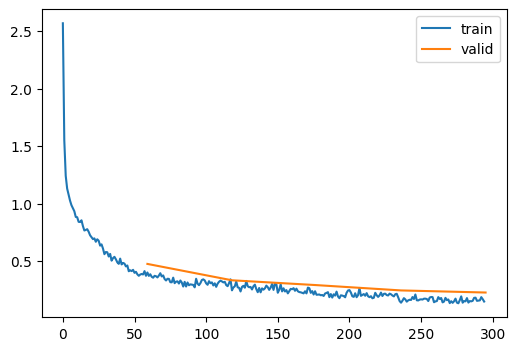

In [ ]:
learn.fit(epochs)

## Skip Connections

The ResNet (*residual network*) was introduced in 2015 by Kaiming He et al in the article ["Deep Residual Learning for Image Recognition"](https://arxiv.org/abs/1512.03385). The key idea is using a *skip connection* to allow deeper networks to train successfully.

![](images/att_00042.png")

In [ ]:
#|export
def _conv_block(ni, nf, stride, act=act_gr, norm=None, ks=3):
    return nn.Sequential(conv(ni, nf, stride=1, act=act, norm=norm, ks=ks),
                         conv(nf, nf, stride=stride, act=None, norm=norm, ks=ks))

class ResBlock(nn.Module):
    def __init__(self, ni, nf, stride=1, ks=3, act=act_gr, norm=None):
        super().__init__()
        self.convs = _conv_block(ni, nf, stride, act=act, ks=ks, norm=norm)
        self.idconv = fc.noop if ni==nf else conv(ni, nf, ks=1, stride=1, act=None)
        self.pool = fc.noop if stride==1 else nn.AvgPool2d(2, ceil_mode=True)
        self.act = act()

    def forward(self, x): return self.act(self.convs(x) + self.idconv(self.pool(x)))

conv_block为什么有两层

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好问题！`_conv_block` 用两层卷积，而不是一层，主要是因为两层可以让网络在保持感受野合理的同时，学到更丰富的特征变换。

具体来说：

1. **两层卷积 = 更强的表达能力** — 两层 `3×3` 卷积堆叠，效果相当于一层 `5×5` 卷积（感受野更大），但参数量更少（`2×3×3 = 18` vs `5×5 = 25`），而且中间多了一层非线性激活，让网络能学到更复杂的变换。

2. **瓶颈设计 (bottleneck)** — 更深的 ResNet（如 ResNet-50/101）甚至会用三层：`1×1` 降维 → `3×3` 变换 → `1×1` 升维，进一步减少计算量。

但在你看到的这个基础 ResBlock 里：

```python
# 第一层：保持空间大小，提取特征
conv(ni, nf, stride=1, act=act, norm=norm, ks=3)
# 第二层：下采样（如果 stride>1），输出不加激活
conv(nf, nf, stride=stride, act=None, norm=norm, ks=3)
```

两层合起来学到的变换 `F(x)` 再加回输入 `x`，得到 `x + F(x)`，就是残差连接的核心思路。

你想看看如果只用一层卷积做残差块，效果会差多少吗？

<details class='token-usage-details' markdown='1'><summary>$0.0010</summary>

`total=10,880 | in=10,394 | out=486 | cached=62.8% | reasoning=172 | searches=0 | $0.0010`

</details>


**Post-lesson update**: Piotr Czapla noticed that we forgot to include `norm=norm` in the call to `_conv_block` above, so the resnets in the lesson didn't have batchnorm in the resblocks! After fixing this, we discovered that initializing the `conv2` batchnorm weights to zero makes things worse in every model we tried, so we removed that. That init method was originally introduced to handle training extremely deep models (much deeper than we use here) -- it appears from this little test that it might be worse for less deep models.

Piotr Czapla 发现我们在上面调用 _conv_block 时忘记传入 norm=norm，导致课程中的 resnet 在残差块里实际上没有 batchnorm！修复这个问题后，我们又发现将 conv2 的 batchnorm 权重初始化为零会使所有我们测试过的模型效果变差，于是移除了这个操作。这种初始化方法最初是为了训练极深网络（比我们这里用的深得多）而引入的——从这个小小的测试来看，它对较浅的模型可能反而有害。

In [ ]:
def get_model(act=nn.ReLU, nfs=(8,16,32,64,128,256), norm=nn.BatchNorm2d):
    layers = [ResBlock(1, 8, stride=1, act=act, norm=norm)]
    layers += [ResBlock(nfs[i], nfs[i+1], act=act, norm=norm, stride=2) for i in range(len(nfs)-1)]
    layers += [nn.Flatten(), nn.Linear(nfs[-1], 10, bias=False), nn.BatchNorm1d(10)]
    return nn.Sequential(*layers).to(def_device)

In [ ]:
def _print_shape(hook, mod, inp, outp): print(type(mod).__name__, inp[0].shape, outp.shape)
model = get_model()
learn = TrainLearner(model, dls, F.cross_entropy, cbs=[DeviceCB(), SingleBatchCB()])
with Hooks(model, _print_shape) as hooks: learn.fit(1, train=False)

ResBlock torch.Size([2048, 1, 28, 28]) torch.Size([2048, 8, 28, 28])
ResBlock torch.Size([2048, 8, 28, 28]) torch.Size([2048, 16, 14, 14])
ResBlock torch.Size([2048, 16, 14, 14]) torch.Size([2048, 32, 7, 7])
ResBlock torch.Size([2048, 32, 7, 7]) torch.Size([2048, 64, 4, 4])
ResBlock torch.Size([2048, 64, 4, 4]) torch.Size([2048, 128, 2, 2])
ResBlock torch.Size([2048, 128, 2, 2]) torch.Size([2048, 256, 1, 1])
Flatten torch.Size([2048, 256, 1, 1]) torch.Size([2048, 256])
Linear torch.Size([2048, 256]) torch.Size([2048, 10])
BatchNorm1d torch.Size([2048, 10]) torch.Size([2048, 10])


In [ ]:
@fc.patch
def summary(self:Learner):
    res = '|Module|Input|Output|Num params|\n|--|--|--|--|\n'
    tot = 0
    def _f(hook, mod, inp, outp):
        nonlocal res,tot
        nparms = sum(o.numel() for o in mod.parameters())
        tot += nparms
        res += f'|{type(mod).__name__}|{tuple(inp[0].shape)}|{tuple(outp.shape)}|{nparms}|\n'
    with Hooks(self.model, _f) as hooks: self.fit(1, lr=1, train=False, cbs=SingleBatchCB())
    print("Tot params: ", tot)
    print(res)
    # if fc.IN_NOTEBOOK:
    #     from IPython.display import Markdown
    #     return Markdown(res)
    # else: print(res)

In [ ]:
TrainLearner(get_model(), dls, F.cross_entropy, cbs=DeviceCB()).summary()

Tot params:  1228908
|Module|Input|Output|Num params|
|--|--|--|--|
|ResBlock|(2048, 1, 28, 28)|(2048, 8, 28, 28)|712|
|ResBlock|(2048, 8, 28, 28)|(2048, 16, 14, 14)|3696|
|ResBlock|(2048, 16, 14, 14)|(2048, 32, 7, 7)|14560|
|ResBlock|(2048, 32, 7, 7)|(2048, 64, 4, 4)|57792|
|ResBlock|(2048, 64, 4, 4)|(2048, 128, 2, 2)|230272|
|ResBlock|(2048, 128, 2, 2)|(2048, 256, 1, 1)|919296|
|Flatten|(2048, 256, 1, 1)|(2048, 256)|0|
|Linear|(2048, 256)|(2048, 10)|2560|
|BatchNorm1d|(2048, 10)|(2048, 10)|20|



以|ResBlock|(2048, 128, 2, 2)|(2048, 256, 1, 1)|919296|为例子，是怎么计算出参数量的

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

以 `ResBlock(128→256, stride=2)` 为例，它里面有三部分有参数：

| 部分 | 层 | 计算 | 参数量 |
|---|---|---|---|
| **conv1** | Conv2d(128→256, ks=3, stride=1) | 128×256×3² + 256(bias) | 295,168 |
| | BatchNorm2d(256) | 256×2 (γ+β) | 512 |
| **conv2** | Conv2d(256→256, ks=3, stride=2) | 256×256×3² + 256(bias) | 590,080 |
| | BatchNorm2d(256) | 256×2 (γ+β) | 512 |
| **idconv** | Conv2d(128→256, ks=1, stride=1) | 128×256×1² + 256(bias) | 33,024 |

合计：295,168 + 512 + 590,080 + 512 + 33,024 = **919,296** ✓

逐项解释：

- **Conv2d 参数量公式**：`in_channels × out_channels × kernel_size² + out_channels(bias)`
- **BatchNorm2d 参数量**：每个通道有可学习的缩放参数 γ 和偏移 β，所以是 `2 × num_features`
- **idconv** 是恒等映射用的 `1×1` 卷积。因为 `ni=128 ≠ nf=256`，维度不匹配，不能直接用 `noop`（恒等），必须用 `1×1` 卷积把通道数从 128 升到 256。它没有接 BatchNorm。

注意这个 ResBlock 的 stride=2 用的是 **conv2 来下采样**（空间从 2×2 → 1×1），而不是像很多实现那样在 idconv 或 pool 上做下采样。这里的 `self.pool`（AvgPool2d）没有可学习参数。

<details class='token-usage-details' markdown='1'><summary>$0.0078</summary>

`total=13,951 | in=12,113 | out=1,838 | cached=31.7% | reasoning=1,394 | searches=0 | $0.0078`

</details>


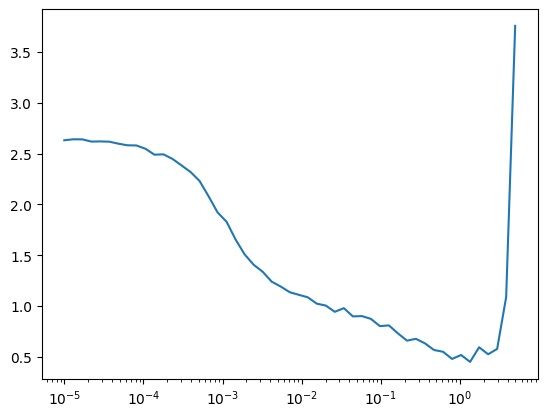

In [ ]:
model = get_model(act_gr, norm=nn.BatchNorm2d).apply(iw)
MomentumLearner(model, dls, F.cross_entropy, cbs=DeviceCB()).lr_find()

In [ ]:
lr = 2e-2
tmax = epochs * len(dls.train)
sched = partial(lr_scheduler.OneCycleLR, max_lr=lr, total_steps=tmax)
xtra = [BatchSchedCB(sched)]
model = get_model(act_gr, norm=nn.BatchNorm2d).apply(iw)
learn = TrainLearner(model, dls, F.cross_entropy, lr=lr, cbs=cbs+xtra, opt_func=optim.AdamW)

accuracy,loss,epoch,train
0.817,0.709,0,train
0.845,0.511,0,eval
0.894,0.347,1,train
0.860,0.431,1,eval
0.913,0.258,2,train
0.907,0.276,2,eval
0.934,0.195,3,train
0.923,0.227,3,eval
0.952,0.148,4,train
0.928,0.215,4,eval


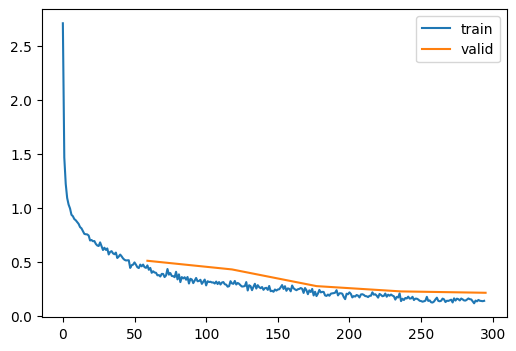

In [ ]:
learn.fit(epochs)

In [ ]:
# 方法1：用 %pip magic（IPython 内置，自动绑定当前 kernel 的 pip）
%pip show timm

Name: timm
Version: 1.0.27
Summary: PyTorch Image Models
Home-page: https://github.com/huggingface/pytorch-image-models
Author: 
Author-email: Ross Wightman <ross@huggingface.co>
License: Apache-2.0
Location: /home/tzyy/miniconda3/envs/fastai/lib/python3.12/site-packages
Requires: huggingface_hub, pyyaml, safetensors, torch, torchvision
Required-by: 


Note: you may need to restart the kernel to use updated packages.


In [ ]:
import timm
from timm.models.resnet import BasicBlock, ResNet, Bottleneck

BasicBlock和Bottleneck分别是什么功能模块

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Let me look up the timm source to give you precise details.


<details class='tool-usage-details' markdown='1'>
<summary><code>read_url(url=&#x27;https://raw.githubusercontent.com/huggin…&#x27;, as_md=&#x27;False&#x27;)→&#x27;&lt;pre&gt;-----------------------------------…&#x27;</code></summary>

```json
{
  "id": "call_00_l7KcTLfhyIgyxrxWTIqS0355",
  "call": {
    "function": "read_url",
    "arguments": {
      "url": "https://raw.githubusercontent.com/huggingface/pytorch-image-models/main/timm/models/resnet.py",
      "as_md": "False"
    }
  },
  "result": "<pre>---------------------------------------------------------------------------\nNameError                                 Traceback (most recent call last)\nCell In[29], line 1\n----> 1 await call_tool(read_url, {'url': 'https://raw.githubusercontent.com/huggingface/pytorch-image-models/main/timm/models/resnet.py', 'as_md': False})\n\nNameError: name 'call_tool' is not defined</pre>"
}
```

</details>





Let me try that differently — I'll search for the timm ResNet source to get the exact definitions of BasicBlock and Bottleneck.


<details class='tool-usage-details' markdown='1'>
<summary><code>search(q=&#x27;timm resnet BasicBlock Bottleneck source…&#x27;)→&#x27;&lt;pre&gt;-----------------------------------…&#x27;</code></summary>

```json
{
  "id": "call_00_nge7QHg2bNSKNKjL9WZz5897",
  "call": {
    "function": "search",
    "arguments": {
      "q": "timm resnet BasicBlock Bottleneck source code pytorch-image-models"
    }
  },
  "result": "<pre>---------------------------------------------------------------------------\nNameError                                 Traceback (most recent call last)\nCell In[30], line 1\n----> 1 await call_tool(search, {'q': 'timm resnet BasicBlock Bottleneck source code pytorch-image-models'})\n\nNameError: name 'call_tool' is not defined</pre>"
}
```

</details>





Let me look at the actual source directly:


<details class='tool-usage-details' markdown='1'>
<summary><code>read_url(url=&#x27;https://raw.githubusercontent.com/huggin…&#x27;, as_md=&#x27;True&#x27;)→&#x27;&lt;pre&gt;-----------------------------------…&#x27;</code></summary>

```json
{
  "id": "call_00_wMIsETQBtVrSwUV696RE0063",
  "call": {
    "function": "read_url",
    "arguments": {
      "url": "https://raw.githubusercontent.com/huggingface/pytorch-image-models/main/timm/models/resnet.py",
      "as_md": "True"
    }
  },
  "result": "<pre>---------------------------------------------------------------------------\nNameError                                 Traceback (most recent call last)\nCell In[31], line 1\n----> 1 await call_tool(read_url, {'url': 'https://raw.githubusercontent.com/huggingface/pytorch-image-models/main/timm/models/resnet.py', 'as_md': True})\n\nNameError: name 'call_tool' is not defined</pre>"
}
```

</details>





好的，让我基于 ResNet 论文和 timm 的实现来解释这两个模块。你刚才从 `timm.models.resnet` 导入了它们。

**BasicBlock** 和 **Bottleneck** 都是 ResNet 的核心构建块，区别在于深度和效率：

---

### BasicBlock（用于 ResNet-18 / ResNet-34）

```
输入 → [3×3 Conv, BN, ReLU] → [3×3 Conv, BN] → +skip → ReLU → 输出
```

两层 `3×3` 卷积，就和你之前看到的 `_conv_block` 一模一样。结构简单，适合不太深的网络（≤34 层）。

### Bottleneck（用于 ResNet-50 / 101 / 152）

```
输入 → [1×1 Conv, BN, ReLU] → [3×3 Conv, BN, ReLU] → [1×1 Conv, BN] → +skip → ReLU → 输出
```

三层卷积，`1×1` 先**降维**（比如 256 → 64），中间 `3×3` 做空间变换，最后 `1×1` 再**升维**回去（64 → 256）。像"压缩-处理-解压"的流程。

---

### 为什么 Bottleneck 效率更高？

| | BasicBlock (256→256) | Bottleneck (256→256) |
|---|---|---|
| 卷积序列 | `3×3,256` → `3×3,256` | `1×1,64` → `3×3,64` → `1×1,256` |
| 参数量 | 256×256×3²×2 ≈ **1.18M** | 256×64×1² + 64×64×3² + 64×256×1² ≈ **70K** |

参数差了约 **17 倍**！所以 Bottleneck 允许堆叠到 50、101、甚至 152 层还不至于参数量爆炸。timm 中，`BasicBlock` 的默认扩张比是 `expansion=1`，而 `Bottleneck` 是 `expansion=4`（中间通道 = 输入通道 ÷ 4），正是这个设计。

你想看看 timm 里它们的实际源码吗？可以直接 `??BasicBlock` 查看。

<details class='token-usage-details' markdown='1'><summary>$0.0065</summary>

`total=57,480 | in=56,215 | out=1,265 | cached=86.8% | reasoning=496 | searches=0 | $0.0065`

</details>


Bottleneck的下一层网络要怎么设计，BasicBlock 的默认扩张比是 expansion=1，而 Bottleneck 是 expansion=4，是否会导致后续层参数量反过来

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好问题！让我先澄清一个关键点，这个容易搞混——

### expansion 不是"放大到下一层"，而是"块内部的压缩比"

Bottleneck 的工作方式是：

```
块输入(256ch) → 1×1压到64ch → 3×3处理 → 1×1扩回256ch → 输出(256ch)
                                        ↑  expansion=4 指这个回扩倍数
```

所以每个 Bottleneck 块的**输入和输出通道数是一样的**（都是 256），expansion 发生在块内部，对下一层完全透明。

---

### 那下一层会发生什么？

ResNet 按阶段组织，阶段之间才会改变通道数。以 ResNet-50 为例：

| 阶段 | 输出通道 | 内部瓶颈通道 | 说明 |
|---|---|---|---|
| conv2_x | 256 | 64 | 块间接口都是 256 |
| conv3_x | 512 | 128 | 阶段切换：256→512 |
| conv4_x | 1024 | 256 | 阶段切换：512→1024 |
| conv5_x | 2048 | 512 | 阶段切换：1024→2048 |

阶段切换时，**输出通道翻倍、内部瓶颈也翻倍**，所以参数不会"反弹"。具体来说，进入 conv3_x 的第一块：

```
输入 256ch → 1×1→128(瓶颈) → 3×3→128 → 1×1→512(输出)
```

参数量：`256×128×1² + 128×128×3² + 128×512×1²` ≈ **245K**

而如果用 BasicBlock 同样 256→512 通道：

```
输入 256ch → 3×3→512 → 3×3→512
```

参数量：`256×512×3² + 512×512×3²` ≈ **3.54M**

差了 **14 倍**！Bottleneck 反而是靠内部压缩在保护后续层不炸。

---

总结一句：expansion=4 的意思是"外面宽，里面窄"，块与块之间接口是宽的那个，内部运算在窄的上面跑。阶段切换时宽和窄同步翻倍，整体平衡。

<details class='token-usage-details' markdown='1'><summary>$0.0014</summary>

`total=15,831 | in=14,785 | out=1,046 | cached=99.6% | reasoning=565 | searches=0 | $0.0014`

</details>


In [ ]:
' '.join(timm.list_models('*resnet*'))

'cspresnet50 cspresnet50d cspresnet50w eca_resnet33ts ecaresnet26t ecaresnet50d ecaresnet50d_pruned ecaresnet50t ecaresnet101d ecaresnet101d_pruned ecaresnet200d ecaresnet269d ecaresnetlight gcresnet33ts gcresnet50t inception_resnet_v2 lambda_resnet26rpt_256 lambda_resnet26t lambda_resnet50ts legacy_seresnet18 legacy_seresnet34 legacy_seresnet50 legacy_seresnet101 legacy_seresnet152 nf_ecaresnet26 nf_ecaresnet50 nf_ecaresnet101 nf_resnet26 nf_resnet50 nf_resnet101 nf_seresnet26 nf_seresnet50 nf_seresnet101 resnet10t resnet14t resnet18 resnet18d resnet26 resnet26d resnet26t resnet32ts resnet33ts resnet34 resnet34d resnet50 resnet50_clip resnet50_clip_gap resnet50_gn resnet50_mlp resnet50c resnet50d resnet50s resnet50t resnet50x4_clip resnet50x4_clip_gap resnet50x16_clip resnet50x16_clip_gap resnet50x64_clip resnet50x64_clip_gap resnet51q resnet61q resnet101 resnet101_clip resnet101_clip_gap resnet101c resnet101d resnet101s resnet152 resnet152c resnet152d resnet152s resnet200 resnet200d 

```
resnet18:  block=BasicBlock, layers=[2, 2, 2, 2]
resnet18d: block=BasicBlock, layers=[2, 2, 2, 2], stem_width=32, stem_type='deep', avg_down=True
resnet10t: block=BasicBlock, layers=[1, 1, 1, 1], stem_width=32, stem_type='deep_tiered', avg_down=True
```

解读上个note单元格

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

那个 note 单元格展示了三种 ResNet 变体的配置，用参数化的方式定义了网络结构：

---

### `layers` — 每阶段堆几个块

ResNet 有 4 个阶段（conv2～conv5）。`layers=[2,2,2,2]` 意思是每个阶段各放 2 个块，总块数 = 2+2+2+2 = 8，对应 8×层数 + 开头一个 conv + 末尾 fc → 总共 **18 层**，所以叫 resnet18。

`resnet10t` 的 `layers=[1,1,1,1]` 就是每阶段只放 1 个块，更浅更快。

---

### `stem_width=32` & `stem_type='deep'` — 入口更精致的预处理

标准 ResNet 入口（stem）就是一层 7×7 卷积。`stem_type='deep'` 把它换成**三层 3×3 卷积**，用 `stem_width=32` 控制输出通道：

```
原版 stem:  [7×7 Conv, 64ch]
deep stem:  [3×3, 32ch] → [3×3, 32ch] → [3×3, 64ch]
```

感受野不变（三个 3×3 ≈ 一个 7×7），但表达力更强、参数更少。

`deep_tiered` 是 deep 的变种，通道从一半(16)开始。

---

### `avg_down=True` — 用平均池化做下采样

原始 ResNet 阶段切换时，shortcut 用 `1×1 Conv(stride=2)` 做下采样。`avg_down=True` 改成先用 `AvgPool2d(2)` 缩小空间，再接 `1×1 Conv(stride=1)` 匹配通道。这样做信息损失更小，已经被很多工作证明效果更好。

---

### 对比总结

| | resnet18 | resnet18d | resnet10t |
|---|---|---|---|
| 深度 | 18 层 | 18 层 | 10 层 |
| 入口 | 单层 7×7 | 三层 3×3 | 三层 3×3(tiered) |
| 下采样 | Conv stride=2 | AvgPool | AvgPool |
| 用途 | 经典基准 | 精度略高 | 轻量快速 |

可以看到 timm 的设计哲学：用几个"开关"（`layers` / stem / avg_down）就能组合出几十种灵活性极高的变体。

<details class='token-usage-details' markdown='1'><summary>$0.0027</summary>

`total=16,949 | in=16,246 | out=703 | cached=82.7% | reasoning=140 | searches=0 | $0.0027`

</details>


In [ ]:
model = timm.create_model('resnet18d', in_chans=1, num_classes=10)
# model = ResNet(in_chans=1, block=BasicBlock, layers=[2,2,2,2], stem_width=32, avg_down=True)

In [ ]:
lr = 2e-2
tmax = epochs * len(dls.train)
sched = partial(lr_scheduler.OneCycleLR, max_lr=lr, total_steps=tmax)
xtra = [BatchSchedCB(sched)]
learn = TrainLearner(model, dls, F.cross_entropy, lr=lr, cbs=cbs+xtra, opt_func=optim.AdamW)

accuracy,loss,epoch,train
0.780,0.631,0,train
0.696,1.310,0,eval
0.875,0.334,1,train
0.834,0.519,1,eval
0.906,0.251,2,train
0.887,0.315,2,eval
0.927,0.194,3,train
0.909,0.245,3,eval
0.945,0.147,4,train
0.918,0.227,4,eval


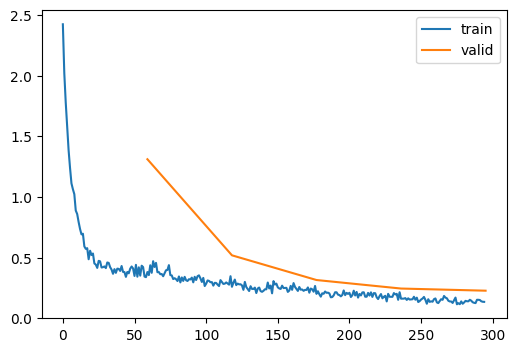

In [ ]:
learn.fit(epochs)

## Export -

In [ ]:
import nbdev; nbdev.nbdev_export()